# Triple Products

Cycle-test circuits for measuring the real parts of triple products `Re tr(σ_i σ_j σ_k)` for WH orbit states in `cirq_sic`.

In [1]:
from math import comb
import numpy as np
import cirq

from cirq_sic import *

In [2]:
d = 4
phi = load_sic_fiducial(d)
prepare_fiducial = ansatz_circuit(phi)

triples = [(0, 0), (1, 0), (2, 1)]
prepare_states = [
    (lambda qubits, a1=a1, a2=a2: wh_state(qubits, prepare_fiducial, a1, a2))
    for a1, a2 in triples
]

qubits = cirq.LineQubit.range(1 + 3 * int(np.log2(d)))
control_qubit = qubits[0]
n = int(np.log2(d))
register1 = qubits[1 : 1 + n]
register2 = qubits[1 + n : 1 + 2 * n]
register3 = qubits[1 + 2 * n : 1 + 3 * n]

circuit = triple_product_measurement_circuit(
    control_qubit,
    register1,
    register2,
    register3,
    prepare_states[0],
    prepare_states[1],
    prepare_states[2],
)

probabilities = exact_simulation(circuit)
measured_value = real_triple_product_from_probabilities(probabilities)

orbit_states = wh_frame(phi).T
orbit_projectors = [np.outer(psi, psi.conj()) for psi in orbit_states]
indices = [a1 * d + a2 for a1, a2 in triples]
expected_value = np.trace(
    orbit_projectors[indices[0]]
    @ orbit_projectors[indices[1]]
    @ orbit_projectors[indices[2]]
).real

print('Measured:', measured_value)
print('Expected:', expected_value)
print('Close:', np.allclose(measured_value, expected_value))

circuit

Measured: -0.029247046
Expected: -0.029247125175112895
Close: True


┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐
0: ───H────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────X────────@────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────H───M('result')───
                                                                                                                                                           │        │    │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │
1: ───Rz(1.63π)────Ry(0.566π)───Rz(0.133π)───@─────────────────@─────────────────@─────────────────@───H───@───────────────×───×─────────@────────H────────@────────X────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────┼───┼───────┼─────────────┼──────────┼───┼──────────┼───┼───────────┼───┼───┼────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────┼───┼───────┼─────────────┼──────────┼───┼──────────┼───┼───────────┼───┼───┼────┼────────────────────────────
                                             │                 │                 │                 │       │               │   │         │                               │             │              │              │               │        │          │   │       │             │          │   │          │   │           │   │   │    │                      │             │              │              │               │        │          │   │       │             │          │   │          │   │           │   │   │    │
2: ───Ry(0.636π)─────────────────────────────X───Ry(-0.197π)───X───Rz(-0.338π)───X───Rz(-0.633π)───X───────@^0.5───H───────×───×───H─────@^-0.5──────────────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5──────────────────────
                                                                                                                                                                         │             │              │              │               │        │                      │             │              │              │               │        │                      │             │              │              │               │        │                      │             │              │              │               │        │
3: ───Rz(1.63π)────Ry(0.566π)───Rz(0.133π)───@─────────────────@─────────────────@─────────────────@───H───@───────────────×───Z───×──────────────@────────H─────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────────────────@─────H───T───X───T──────────X───T^-1───────X───T^-1────────X────────X──────────H───S^-1────┼─────────────┼─────

In [3]:
d = 2
phi = load_sic_fiducial(d)

task = CharacterizeWHTripleProductsTask(
    dataset_id='notebook',
    processor_id='willow_pink',
    run_type='clean',
    qubits=get_triple_product_qubits(d),
    n_shots=500,
    optimizer='cirq',
    d=d,
    fiducial=phi,
    fiducial_description='numerical_sic',
)

tensor_exact = exactify(task)['T']
orbit_states = wh_frame(phi).T
orbit_projectors = [np.outer(psi, psi.conj()) for psi in orbit_states]
tensor_numpy = np.array([
    [[np.trace(rho_i @ rho_j @ rho_k).real for rho_k in orbit_projectors]
     for rho_j in orbit_projectors]
    for rho_i in orbit_projectors
])

print('Unique circuits:', len(task.make_circuits()), 'of', comb(d**2 + 2, 3))
print('Tensor shape:', tensor_exact.shape)
print('Symmetric:', np.allclose(tensor_exact, np.transpose(tensor_exact, (1, 0, 2))))
print('Matches NumPy:', np.allclose(tensor_exact, tensor_numpy))

base_dir = 'tmp_triple_products'
run_sky_ground_task(task, base_dir=base_dir)
results = load_results(task, base_dir=base_dir)
tensor_empirical = np.array(results["processed_data"]["T"])

Unique circuits: 20 of 20
Tensor shape: (4, 4, 4)
Symmetric: True
Matches NumPy: False
2026-06-24 19:13:02 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Starting task...
2026-06-24 19:13:02 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Creating circuits...
2026-06-24 19:13:02 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Optimizing circuits...
2026-06-24 19:13:10 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Sampling...
2026-06-24 19:13:11 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Processing results...
2026-06-24 19:13:11 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Saving...


In [4]:
def sample_valid_probabilities(N, T):
    n = T.shape[0]
    d = int(np.sqrt(n))

    P = np.sum(T, axis=0)/d**2
    Phi = np.linalg.pinv(P)

    rng = np.random.default_rng()
    p = rng.dirichlet(np.ones(n), size=N).T
    L = np.einsum("ijk,kl->lij", T, Phi @ p)
    valid = np.all(np.linalg.eigvals(L)>=0, axis=1)
    valid_p = p.T[valid]
    return valid_p

## Hulls

In [10]:
from scipy.spatial import ConvexHull, Delaunay
import math


def simplex_center(n_outcomes):
    return np.ones(n_outcomes) / n_outcomes


def _simplex_projection_basis(n_outcomes):
    if n_outcomes < 2:
        raise ValueError('Need at least two outcomes to define a simplex hyperplane.')

    raw_basis = np.zeros((n_outcomes, n_outcomes - 1), dtype=float)
    raw_basis[:-1, :] = np.eye(n_outcomes - 1)
    raw_basis[-1, :] = -1
    orthonormal_basis, _ = np.linalg.qr(raw_basis)
    return orthonormal_basis[:, : n_outcomes - 1]


def project_probability_vectors(probabilities, basis=None):
    probabilities = np.asarray(probabilities, dtype=float)
    if probabilities.ndim != 2:
        raise ValueError('Expected an array of shape (n_points, n_outcomes).')

    n_outcomes = probabilities.shape[1]
    center = simplex_center(n_outcomes)
    if basis is None:
        basis = _simplex_projection_basis(n_outcomes)
    return (probabilities - center) @ basis


def prepare_probability_hull(valid_p, *, max_hull_points=1500, seed=0, rounding_decimals=10):
    rng = np.random.default_rng(seed)
    intrinsic_points = project_probability_vectors(valid_p)
    intrinsic_points = np.unique(np.round(intrinsic_points, decimals=rounding_decimals), axis=0)

    if len(intrinsic_points) > max_hull_points:
        indices = rng.choice(len(intrinsic_points), size=max_hull_points, replace=False)
        intrinsic_points = intrinsic_points[indices]

    hull = ConvexHull(intrinsic_points, qhull_options='QJ')
    hull_vertices = intrinsic_points[hull.vertices]
    triangulation = Delaunay(hull_vertices, qhull_options='QJ')
    simplices = triangulation.simplices
    simplices_points = hull_vertices[simplices]

    affine_dim = intrinsic_points.shape[1]
    simplex_mats = simplices_points[:, 1:] - simplices_points[:, :1]
    simplex_volumes = np.abs(np.linalg.det(simplex_mats)) / math.factorial(affine_dim)
    simplex_weights = simplex_volumes / simplex_volumes.sum()

    return {
        'n_outcomes': valid_p.shape[1],
        'intrinsic_points': intrinsic_points,
        'hull': hull,
        'hull_vertices': hull_vertices,
        'simplices_points': simplices_points,
        'simplex_weights': simplex_weights,
    }


def sample_uniform_from_hull(prepared_hull, n_samples, *, seed=0):
    rng = np.random.default_rng(seed)
    simplices_points = prepared_hull['simplices_points']
    affine_dim = simplices_points.shape[2]

    simplex_indices = rng.choice(
        len(simplices_points),
        size=n_samples,
        p=prepared_hull['simplex_weights'],
    )
    chosen_simplices = simplices_points[simplex_indices]

    barycentric = rng.dirichlet(np.ones(affine_dim + 1), size=n_samples)
    return np.einsum('ni,nij->nj', barycentric, chosen_simplices)


def points_in_hull(points, prepared_hull, tol=1e-9):
    points = np.asarray(points, dtype=float)
    A = prepared_hull['hull'].equations[:, :-1]
    b = prepared_hull['hull'].equations[:, -1]
    return np.all(A @ points.T + b[:, None] <= tol, axis=0)


def estimate_hull_outside_proportions(prepared_a, prepared_b, *, n_samples=20000, seed=0):
    if prepared_a['n_outcomes'] != prepared_b['n_outcomes']:
        raise ValueError('Both hulls must come from the same probability-vector dimension.')

    samples_a = sample_uniform_from_hull(prepared_a, n_samples, seed=seed)
    samples_b = sample_uniform_from_hull(prepared_b, n_samples, seed=seed + 1)

    prop_a_outside_b = 1 - points_in_hull(samples_a, prepared_b).mean()
    prop_b_outside_a = 1 - points_in_hull(samples_b, prepared_a).mean()

    stderr_a = np.sqrt(prop_a_outside_b * (1 - prop_a_outside_b) / n_samples)
    stderr_b = np.sqrt(prop_b_outside_a * (1 - prop_b_outside_a) / n_samples)

    return {
        'prop_a_outside_b': prop_a_outside_b,
        'prop_b_outside_a': prop_b_outside_a,
        'stderr_a': stderr_a,
        'stderr_b': stderr_b,
    }


N = 100000
valid_p = sample_valid_probabilities(N, tensor_empirical)
valid_p_exact = sample_valid_probabilities(N, tensor_exact)

prepared_valid = prepare_probability_hull(valid_p, seed=0)
prepared_valid_exact = prepare_probability_hull(valid_p_exact, seed=1)

comparison = estimate_hull_outside_proportions(
    prepared_valid,
    prepared_valid_exact,
    n_samples=20000,
    seed=123,
)

print('Proportion of hull(valid_p) outside hull(valid_p_exact):', comparison['prop_a_outside_b'])
print('Monte Carlo stderr:', comparison['stderr_a'])
print('Proportion of hull(valid_p_exact) outside hull(valid_p):', comparison['prop_b_outside_a'])
print('Monte Carlo stderr:', comparison['stderr_b'])

Proportion of hull(valid_p) outside hull(valid_p_exact): 0.07779999999999998
Monte Carlo stderr: 0.0018940322066955458
Proportion of hull(valid_p_exact) outside hull(valid_p): 0.17610000000000003
Monte Carlo stderr: 0.0026934066718562943


## d=2 viz

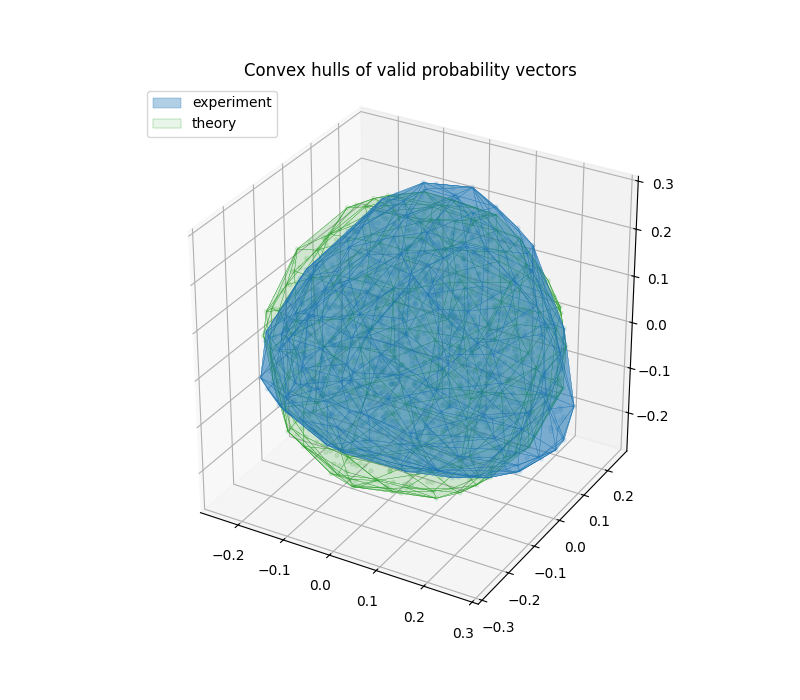

In [11]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def fit_plot_projection(prepared_hulls, plot_dim=3):
    stacked = np.vstack([prepared['intrinsic_points'] for prepared in prepared_hulls])
    centered = stacked - stacked.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    n_components = min(plot_dim, vh.shape[0])
    return vh[:n_components].T


def _embed_for_3d(points):
    points = np.asarray(points, dtype=float)
    if points.shape[1] >= 3:
        return points[:, :3]
    padding = np.zeros((points.shape[0], 3 - points.shape[1]))
    return np.hstack([points, padding])


def _set_equal_3d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    if radius == 0:
        radius = 1.0

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))


def plot_prepared_probability_hulls(
    prepared_hulls,
    *,
    colors=None,
    labels=None,
    alphas=None,
):
    if colors is None:
        colors = [f'C{i}' for i in range(len(prepared_hulls))]
    if labels is None:
        labels = [f'set {i + 1}' for i in range(len(prepared_hulls))]
    if alphas is None:
        alphas = [0.28] * len(prepared_hulls)

    plot_basis = fit_plot_projection(prepared_hulls, plot_dim=3)

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    legend_handles = []
    all_plot_points = []

    for prepared, color, label, alpha in zip(prepared_hulls, colors, labels, alphas):
        plot_points = _embed_for_3d(prepared['intrinsic_points'] @ plot_basis)
        hull_faces = [_embed_for_3d(prepared['intrinsic_points'][simplex] @ plot_basis) for simplex in prepared['hull'].simplices]

        all_plot_points.append(plot_points)
        ax.scatter(plot_points[:, 0], plot_points[:, 1], plot_points[:, 2], s=8, alpha=0.12, color=color)

        poly = Poly3DCollection(
            hull_faces,
            facecolor=color,
            edgecolor=color,
            linewidth=0.2,
            alpha=alpha,
        )
        ax.add_collection3d(poly)
        legend_handles.append(poly)

    stacked = np.vstack(all_plot_points)
    _set_equal_3d_axes(ax, stacked)
    ax.set_title('Convex hulls of valid probability vectors')
    ax.legend(legend_handles, labels, loc='upper left')
    plt.show()


plot_prepared_probability_hulls(
    [prepared_valid, prepared_valid_exact],
    colors=['C0', 'C2'],
    labels=['experiment', 'theory'],
    alphas=[0.35, 0.1],
)